# Audit · 01_initialize_embeddings

Este notebook es una verificación independiente del checkpoint producido por `01_initialize_embeddings.ipynb`. No modifica ni vuelve a inicializar pesos. Carga el modelo guardado y comprueba la integridad del checkpoint, las ecuaciones de cada familia, el weight tying y la compatibilidad de normas con ChemBERTa.

## Criterios de aceptación

1. Matriz `899 × 768`, IDs y familias correctos.
2. Las filas 0–766 son idénticas al checkpoint base.
3. Embeddings de entrada y decoder MLM continúan ligados.
4. Los 17 elementos transferibles son copias exactas de su token químico.
5. Los 67 fallbacks siguen la geometría neutral declarada.
6. Los nodos tienen offsets ortogonales y ninguna estructura ordinal.
7. Las traslaciones satisfacen oposición y composición en tres ejes.
8. `[SLICES]` coincide con su centro especial y perturbación.
9. Las normas nuevas permanecen entre los percentiles 1 y 99 del vocabulario base.

In [1]:
from hashlib import sha256
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForMaskedLM, AutoTokenizer

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        marker = candidate / 'transferability' / 'initialize' / 'artifacts' / 'initialization_manifest.json'
        if marker.exists():
            return candidate
    raise FileNotFoundError('No se encontró initialization_manifest.json.')

PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACT_ROOT = PROJECT_ROOT / 'transferability' / 'initialize' / 'artifacts'
MODEL_DIR = ARTIFACT_ROOT / 'chemberta_slices_initialized'
TABLE_PATH = ARTIFACT_ROOT / 'initialization_table.csv'
GEOMETRY_PATH = ARTIFACT_ROOT / 'initialization_geometry.npz'
MANIFEST_PATH = ARTIFACT_ROOT / 'initialization_manifest.json'
RESULTS_DIR = PROJECT_ROOT / 'transferability' / 'initialize' / 'audit' / 'results'
CACHE_DIR = PROJECT_ROOT / '.cache' / 'huggingface'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
table = pd.read_csv(TABLE_PATH)
geometry_np = np.load(GEOMETRY_PATH)
geometry = {name: torch.from_numpy(geometry_np[name]).float() for name in geometry_np.files}
print(f'Esquema: {manifest["schema"]}')
print(f'Checkpoint: {MODEL_DIR.relative_to(PROJECT_ROOT)}')

Esquema: SLICES-embedding-init-v1
Checkpoint: transferability/initialize/artifacts/chemberta_slices_initialized


## 1. Carga independiente e integridad de archivos

Las huellas del manifiesto detectan archivos incompletos o modificados después de la inicialización. Después se cargan tanto el checkpoint base como el inicializado.

In [2]:
checks = []

def add_check(name: str, passed: bool, value=None, tolerance=None, detail: str = '') -> None:
    checks.append({
        'check': name, 'passed': bool(passed), 'value': value,
        'tolerance': tolerance, 'detail': detail,
    })

hash_results = []
for filename, expected in manifest['files'].items():
    path = MODEL_DIR / filename
    actual_hash = sha256(path.read_bytes()).hexdigest() if path.exists() else ''
    valid = path.exists() and path.stat().st_size == expected['bytes'] and actual_hash == expected['sha256']
    hash_results.append({'archivo': filename, 'válido': valid, 'bytes': path.stat().st_size if path.exists() else 0})
add_check('hashes del checkpoint', all(row['válido'] for row in hash_results),
          value=sum(row['válido'] for row in hash_results), tolerance=len(hash_results))
display(pd.DataFrame(hash_results))

base_tokenizer = AutoTokenizer.from_pretrained(
    manifest['base_model']['name'], revision=manifest['base_model']['revision'],
    cache_dir=CACHE_DIR, local_files_only=True,
)
base_model = AutoModelForMaskedLM.from_pretrained(
    manifest['base_model']['name'], revision=manifest['base_model']['revision'],
    cache_dir=CACHE_DIR, local_files_only=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForMaskedLM.from_pretrained(MODEL_DIR, local_files_only=True)
base_model.eval(); model.eval()

base_weight = base_model.get_input_embeddings().weight.detach().cpu().float()
weight = model.get_input_embeddings().weight.detach().cpu().float()
output_weight = model.get_output_embeddings().weight
OLD_SIZE = manifest['architecture']['old_vocab_size']
NEW_SIZE = manifest['architecture']['new_vocab_size']
HIDDEN_SIZE = manifest['architecture']['hidden_size']

add_check('forma de embeddings', tuple(weight.shape) == (NEW_SIZE, HIDDEN_SIZE),
          value=str(tuple(weight.shape)), tolerance=str((NEW_SIZE, HIDDEN_SIZE)))
add_check('longitud del tokenizer', len(tokenizer) == NEW_SIZE, value=len(tokenizer), tolerance=NEW_SIZE)
add_check('weight tying', model.get_input_embeddings().weight.data_ptr() == output_weight.data_ptr())
add_check('bias MLM redimensionado', model.get_output_embeddings().bias.shape[0] == NEW_SIZE,
          value=model.get_output_embeddings().bias.shape[0], tolerance=NEW_SIZE)

,archivo,válido,bytes
0,config.json,True,958
1,model.safetensors,True,176843444
2,tokenizer.json,True,62026
3,tokenizer_config.json,True,452


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

[transformers] RobertaForMaskedLM LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

## 2. Filas base, IDs y conteos

El resize no debe alterar conocimiento preentrenado. También se verifica que los 132 IDs nuevos sean únicos y correspondan al tokenizer guardado.

In [3]:
base_max_error = torch.max(torch.abs(weight[:OLD_SIZE] - base_weight)).item()
add_check('filas 0–766 intactas', base_max_error == 0.0, value=base_max_error, tolerance=0.0)

table['token_id'] = table['token_id'].astype(int)
ids_match = all(tokenizer.convert_tokens_to_ids(row.token) == row.token_id for row in table.itertuples(index=False))
add_check('IDs token↔tabla', ids_match)
add_check('132 IDs nuevos únicos', table['token_id'].nunique() == 132 and table['token_id'].min() == OLD_SIZE,
          value=table['token_id'].nunique(), tolerance=132)

expected_counts = {'marcador': 1, 'elemento': 84, 'nodo': 20, 'traslación': 27}
actual_counts = table.groupby('familia').size().to_dict()
add_check('conteos por familia', actual_counts == expected_counts, value=str(actual_counts), tolerance=str(expected_counts))
display(table.groupby(['familia', 'estrategia'], sort=False).size().rename('tokens').to_frame())

tokens
familia    estrategia                                              
marcador   special_centroid_calibrated_plus_small_offset          1
elemento   exact_chemical_token_transfer                         17
           neutral_calibrated_center_plus_orthogonal_offset      67
nodo       digit_centroid_calibrated_plus_orthogonal_offset      20
traslación calibrated_center_plus_structured_3d_basis            27

## 3. Elementos

Los transferibles deben ser copias exactas. Los fallbacks se reconstruyen desde el centro neutral y sus 67 offsets guardados.

In [4]:
transfer_rows = table.query("estrategia == 'exact_chemical_token_transfer'").reset_index(drop=True)
fallback_rows = table.query("estrategia == 'neutral_calibrated_center_plus_orthogonal_offset'").reset_index(drop=True)
alpha_element = float(geometry['alpha_element'])

transfer_errors = []
for row in transfer_rows.itertuples(index=False):
    source_id = int(row.id_fuente)
    transfer_errors.append(torch.max(torch.abs(weight[row.token_id] - base_weight[source_id])).item())
transfer_max_error = max(transfer_errors, default=0.0)
add_check('17 elementos transferidos', len(transfer_rows) == 17, value=len(transfer_rows), tolerance=17)
add_check('transferencia química exacta', transfer_max_error == 0.0, value=transfer_max_error, tolerance=0.0)

fallback_actual = weight[fallback_rows['token_id'].to_numpy()]
fallback_expected = geometry['element_fallback_center'] + alpha_element * geometry['element_offsets']
fallback_max_error = torch.max(torch.abs(fallback_actual - fallback_expected)).item()
fallback_gram = geometry['element_offsets'] @ geometry['element_offsets'].T
fallback_orth_error = torch.max(torch.abs(fallback_gram - torch.eye(len(fallback_rows)))).item()
add_check('67 elementos fallback', len(fallback_rows) == 67, value=len(fallback_rows), tolerance=67)
add_check('fórmula fallback', fallback_max_error < 1e-6, value=fallback_max_error, tolerance=1e-6)
add_check('offsets fallback ortonormales', fallback_orth_error < 1e-5,
          value=fallback_orth_error, tolerance=1e-5)

## 4. Nodos: distinguibles sin orden

Se reconstruye `E(N_i)=centro_N+α_N q_i`. Si los `q_i` son ortonormales y tienen la misma escala, todas las distancias entre nodos distintos son iguales. Por tanto, índices consecutivos no reciben cercanía artificial.

In [5]:
node_rows = table.query("familia == 'nodo'").copy()
node_rows['índice'] = node_rows['token_original'].astype(int)
node_rows = node_rows.sort_values('índice').reset_index(drop=True)
node_actual = weight[node_rows['token_id'].to_numpy()]
alpha_node = float(geometry['alpha_node'])
node_expected = geometry['node_center'] + alpha_node * geometry['node_offsets']
node_formula_error = torch.max(torch.abs(node_actual - node_expected)).item()
node_centered = node_actual - geometry['node_center']
node_gram = node_centered @ node_centered.T / alpha_node**2
node_orth_error = torch.max(torch.abs(node_gram - torch.eye(20))).item()
node_distances = torch.cdist(node_actual, node_actual)
off_diagonal = node_distances[~torch.eye(20, dtype=bool)]
distance_spread = (off_diagonal.max() - off_diagonal.min()).item()
adjacent_mean = torch.diagonal(node_distances, offset=1).mean().item()
nonadjacent_mean = node_distances[torch.triu(torch.ones(20, 20, dtype=bool), diagonal=2)].mean().item()
ordinal_gap = abs(adjacent_mean - nonadjacent_mean)

add_check('fórmula de nodos', node_formula_error < 1e-6, value=node_formula_error, tolerance=1e-6)
add_check('offsets de nodos ortonormales', node_orth_error < 1e-5, value=node_orth_error, tolerance=1e-5)
add_check('distancias de nodos uniformes', distance_spread < 1e-5, value=distance_spread, tolerance=1e-5)
add_check('sin cercanía ordinal', ordinal_gap < 1e-5, value=ordinal_gap, tolerance=1e-5,
          detail=f'adyacentes={adjacent_mean:.8f}, no adyacentes={nonadjacent_mean:.8f}')

## 5. Traslaciones: oposición, ejes y composición

Para cada `xyz` se verifica:

$$E(T_{xyz})=\mu_T+\alpha_T(xb_x+yb_y+zb_z).$$

También se prueban las 13 parejas no nulas de vectores opuestos y la composición explícita `++o = +oo + o+o` alrededor de `ooo`.

In [6]:
translation_rows = table.query("familia == 'traslación'").reset_index(drop=True)
translation_map = {row.token_original: weight[row.token_id] for row in translation_rows.itertuples(index=False)}
value_map = {'-': -1.0, 'o': 0.0, '+': 1.0}
inverse_map = {-1: '-', 0: 'o', 1: '+'}
alpha_translation = float(geometry['alpha_translation'])

formula_errors = []
for token, actual in translation_map.items():
    coordinates = torch.tensor([value_map[value] for value in token])
    expected = geometry['translation_center'] + alpha_translation * (coordinates @ geometry['translation_axes'])
    formula_errors.append(torch.max(torch.abs(actual - expected)).item())
translation_formula_error = max(formula_errors)
axes_gram = geometry['translation_axes'] @ geometry['translation_axes'].T
axes_orth_error = torch.max(torch.abs(axes_gram - torch.eye(3))).item()

zero = translation_map['ooo']
opposite_errors = []
seen = set()
for token, vector in translation_map.items():
    coordinates = tuple(int(value_map[value]) for value in token)
    if coordinates == (0, 0, 0):
        continue
    opposite_coordinates = tuple(-value for value in coordinates)
    opposite = ''.join(inverse_map[value] for value in opposite_coordinates)
    pair = tuple(sorted([token, opposite]))
    if pair not in seen:
        seen.add(pair)
        opposite_errors.append(torch.max(torch.abs((vector - zero) + (translation_map[opposite] - zero))).item())

composition_error = torch.max(torch.abs(
    (translation_map['++o'] - zero)
    - (translation_map['+oo'] - zero)
    - (translation_map['o+o'] - zero)
)).item()

add_check('fórmula de 27 traslaciones', translation_formula_error < 1e-6,
          value=translation_formula_error, tolerance=1e-6)
add_check('tres ejes ortonormales', axes_orth_error < 1e-5, value=axes_orth_error, tolerance=1e-5)
add_check('13 parejas opuestas', len(opposite_errors) == 13 and max(opposite_errors) < 1e-6,
          value=max(opposite_errors), tolerance=1e-6, detail=f'parejas={len(opposite_errors)}')
add_check('composición ++o', composition_error < 1e-6, value=composition_error, tolerance=1e-6)

## 6. Marcador `[SLICES]` y distribución de normas

El marcador debe obedecer su fórmula y todos los tokens nuevos deben quedar dentro del intervalo robusto `[q01, q99]` de normas de las filas originales.

In [7]:
marker_row = table.query("familia == 'marcador'").iloc[0]
alpha_special = float(geometry['alpha_special'])
marker_expected = geometry['slices_center'] + alpha_special * geometry['special_perturbation_direction']
marker_error = torch.max(torch.abs(weight[int(marker_row.token_id)] - marker_expected)).item()
add_check('fórmula [SLICES]', marker_error < 1e-6, value=marker_error, tolerance=1e-6)

global_mean = base_weight.mean(dim=0)
stored_mean_error = torch.max(torch.abs(global_mean - geometry['global_mean'])).item()
digit_ids = torch.tensor([base_tokenizer.convert_tokens_to_ids(str(value)) for value in range(10)])
digit_mean_error = torch.max(torch.abs(base_weight[digit_ids].mean(dim=0) - geometry['digit_mean'])).item()
special_ids = torch.tensor([base_tokenizer.bos_token_id, base_tokenizer.eos_token_id, base_tokenizer.mask_token_id])
special_mean_error = torch.max(torch.abs(base_weight[special_ids].mean(dim=0) - geometry['special_mean'])).item()
add_check('centros derivados del checkpoint', max(stored_mean_error, digit_mean_error, special_mean_error) < 1e-7,
          value=max(stored_mean_error, digit_mean_error, special_mean_error), tolerance=1e-7)

base_norms = torch.linalg.vector_norm(base_weight, dim=1)
new_norms = torch.linalg.vector_norm(weight[table['token_id'].to_numpy()], dim=1)
q01, q99 = torch.quantile(base_norms, torch.tensor([0.01, 0.99])).tolist()
inside = (new_norms >= q01) & (new_norms <= q99)
add_check('normas nuevas dentro de q01–q99', bool(inside.all()),
          value=f'{int(inside.sum())}/{len(inside)}', tolerance=f'{len(inside)}/{len(inside)}',
          detail=f'intervalo=[{q01:.6f}, {q99:.6f}]')

token_metrics = table[['token', 'token_id', 'familia', 'estrategia']].copy()
token_metrics['norma'] = new_norms.numpy()
token_metrics['dentro_q01_q99'] = inside.numpy()
display(token_metrics.groupby(['familia', 'estrategia'], sort=False).agg(
    tokens=('token', 'size'), norma_mín=('norma', 'min'), norma_media=('norma', 'mean'),
    norma_máx=('norma', 'max'), dentro=('dentro_q01_q99', 'sum')
))

tokens  \
familia    estrategia                                                 
marcador   special_centroid_calibrated_plus_small_offset          1   
elemento   exact_chemical_token_transfer                         17   
           neutral_calibrated_center_plus_orthogonal_offset      67   
nodo       digit_centroid_calibrated_plus_orthogonal_offset      20   
traslación calibrated_center_plus_structured_3d_basis            27   

                                                             norma_mín  \
familia    estrategia                                                    
marcador   special_centroid_calibrated_plus_small_offset      0.553286   
elemento   exact_chemical_token_transfer                      0.532662   
           neutral_calibrated_center_plus_orthogonal_offset   0.553286   
nodo       digit_centroid_calibrated_plus_orthogonal_offset   0.553286   
traslación calibrated_center_plus_structured_3d_basis         0.547725   

                                                             norma_media  \
familia    estrategia                                                      
marcador   special_centroid_calibrated_plus_small_offset        0.553286   
elemento   exact_chemical_token_transfer                        0.555428   
           neutral_calibrated_center_plus_orthogonal_offset     0.553286   
nodo       digit_centroid_calibrated_plus_orthogonal_offset     0.553286   
traslación calibrated_center_plus_structured_3d_basis           0.553281   

                                                             norma_máx  dentro  
familia    estrategia                                                           
marcador   special_centroid_calibrated_plus_small_offset      0.553286       1  
elemento   exact_chemical_token_transfer                      0.579668      17  
           neutral_calibrated_center_plus_orthogonal_offset   0.553286      67  
nodo       digit_centroid_calibrated_plus_orthogonal_offset   0.553286      20  
traslación calibrated_center_plus_structured_3d_basis         0.556045      27

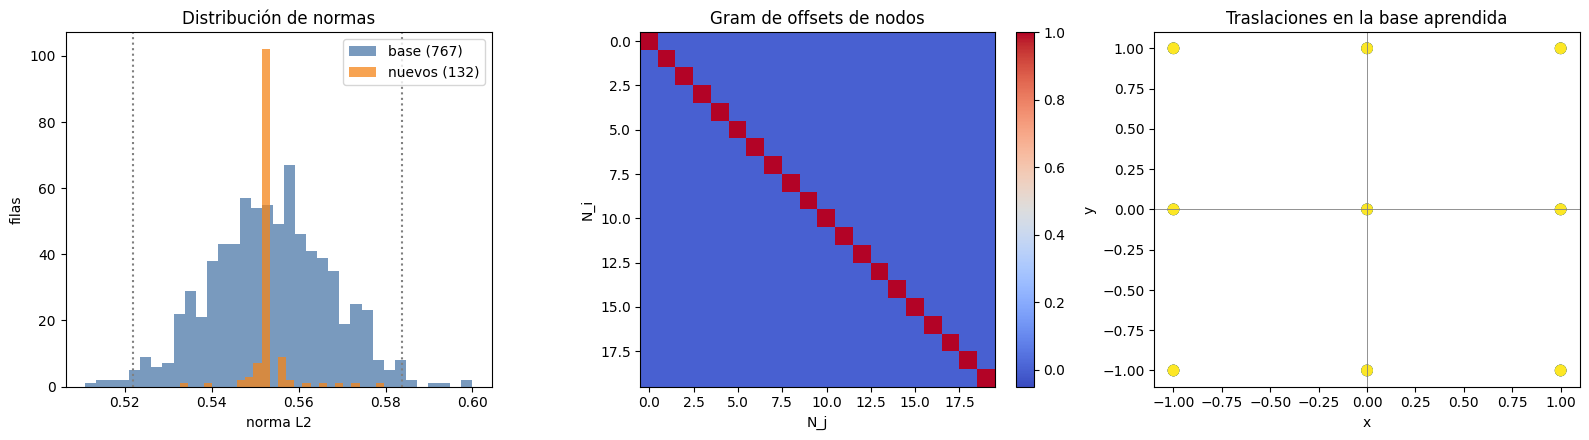

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(base_norms.numpy(), bins=35, alpha=0.75, label='base (767)', color='#4C78A8')
axes[0].hist(new_norms.numpy(), bins=25, alpha=0.75, label='nuevos (132)', color='#F58518')
axes[0].axvline(q01, color='gray', linestyle=':')
axes[0].axvline(q99, color='gray', linestyle=':')
axes[0].set(title='Distribución de normas', xlabel='norma L2', ylabel='filas')
axes[0].legend()

image = axes[1].imshow(node_gram.numpy(), vmin=-0.05, vmax=1.0, cmap='coolwarm')
axes[1].set(title='Gram de offsets de nodos', xlabel='N_j', ylabel='N_i')
fig.colorbar(image, ax=axes[1], fraction=0.046)

translation_deltas = torch.stack([translation_map[token] - zero for token in translation_rows['token_original']])
projected = translation_deltas @ geometry['translation_axes'].T / alpha_translation
axes[2].scatter(projected[:, 0], projected[:, 1], c=projected[:, 2], cmap='viridis', s=55)
axes[2].axhline(0, color='gray', linewidth=0.6); axes[2].axvline(0, color='gray', linewidth=0.6)
axes[2].set(title='Traslaciones en la base geométrica de inicialización', xlabel='x', ylabel='y')

plt.tight_layout()
plt.show()

## 7. Resultado y exportación

El audit sólo se considera aprobado si todas las comprobaciones pasan. Se exportan tanto el resumen como las métricas por token para poder comparar futuras estrategias de inicialización.

In [9]:
audit_summary = pd.DataFrame(checks)
display(audit_summary)

failed = audit_summary.loc[~audit_summary['passed']]
if not failed.empty:
    raise AssertionError('Fallaron comprobaciones de inicialización:\n' + failed.to_string(index=False))

SUMMARY_PATH = RESULTS_DIR / '01_initialize_embeddings_audit.csv'
TOKEN_PATH = RESULTS_DIR / '01_initialize_embeddings_token_metrics.csv'
REPORT_PATH = RESULTS_DIR / '01_initialize_embeddings_audit.json'
audit_summary.to_csv(SUMMARY_PATH, index=False)
token_metrics.to_csv(TOKEN_PATH, index=False)
report = {
    'schema': 'SLICES-embedding-init-audit-v1',
    'source_manifest': str(MANIFEST_PATH.relative_to(PROJECT_ROOT)),
    'passed': True, 'checks_passed': int(audit_summary['passed'].sum()),
    'checks_total': len(audit_summary), 'base_rows_max_error': base_max_error,
    'translation_formula_max_error': translation_formula_error,
    'node_orthogonality_max_error': node_orth_error,
    'new_norm_interval': {'q01': q01, 'q99': q99, 'inside': int(inside.sum()), 'total': len(inside)},
}
REPORT_PATH.write_text(json.dumps(report, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')
print(f'AUDIT APROBADO: {len(audit_summary)}/{len(audit_summary)} comprobaciones')
print(SUMMARY_PATH.relative_to(PROJECT_ROOT))
print(TOKEN_PATH.relative_to(PROJECT_ROOT))
print(REPORT_PATH.relative_to(PROJECT_ROOT))

,check,passed,value,tolerance,detail
0,hashes del checkpoint,True,4,4,
1,forma de embeddings,True,"(899, 768)","(899, 768)",
2,longitud del tokenizer,True,899,899,
3,weight tying,True,None,None,
4,bias MLM redimensionado,True,899,899,
5,filas 0–766 intactas,True,0.0,0.0,
6,IDs token↔tabla,True,None,None,
7,132 IDs nuevos únicos,True,132,132,
8,conteos por familia,True,"{'elemento': 84, 'marcador': 1, 'nodo': 20, 'traslación': 27}","{'marcador': 1, 'elemento': 84, 'nodo': 20, 'traslación': 27}",
9,17 elementos transferidos,True,17,17,


AUDIT APROBADO: 25/25 comprobaciones
transferability/initialize/audit/results/01_initialize_embeddings_audit.csv
transferability/initialize/audit/results/01_initialize_embeddings_token_metrics.csv
transferability/initialize/audit/results/01_initialize_embeddings_audit.json
